In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

In [2]:
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/runs/0/edm4hep.root"
batch = EDM4hepEventBatch(edm_input_file, events=(0, 10), full_load=False)

In [3]:
particles = batch.get_particles_df()

In [4]:
generator_particles = particles[particles["created_in_simulation"] == False]
generator_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,0.000000,0.93827,0.000000,0.000000,0.000000,...,6999.999937,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,0,1,1,0,-0.333333,-0.221602,0.00000,-0.011325,-0.007458,116.524419,...,855.719020,0,1,0.013560,855.719020,855.719020,1,False,0,0
2,0,2,2,0,0.666667,-0.221602,0.33000,-0.011325,-0.007458,116.524419,...,1052.295476,1,2,0.013560,1052.295527,1051.965527,2,False,0,0
3,0,3,2103,0,0.333333,-0.221602,0.77133,-0.011325,-0.007458,116.524419,...,2005.069087,2,3,0.013560,2005.069235,2004.297905,3,False,0,0
4,0,4,-1,0,0.333333,-0.221602,0.33000,-0.011325,-0.007458,116.524419,...,3086.916278,3,4,0.013560,3086.916295,3086.586295,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2112632,9,93338,310,0,0.000000,0.400682,0.49761,0.025793,0.003278,52.052604,...,-5.997176,268563,268564,0.026000,6.019028,5.521418,93338,False,0,0
2112633,9,93339,22,16777216,0.000000,0.400683,0.00000,0.025762,0.003214,52.052311,...,-0.268228,268564,268565,0.025961,0.277790,0.277790,93339,False,0,0
2112634,9,93340,22,16777216,0.000000,0.400683,0.00000,0.025762,0.003214,52.052311,...,-1.606659,268565,268566,0.025961,1.652154,1.652154,93340,False,0,0
2112635,9,93341,211,33554432,1.000000,1.868946,0.13957,-8.736305,-1.787310,-386.523638,...,-3.671893,268566,268567,8.917259,3.676882,3.537312,93341,False,0,0


In [5]:
generator_particles[generator_particles.particle_id == 1]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
1,0,1,1,0,-0.333333,-0.221602,0.0,-0.011325,-0.007458,116.524419,...,855.719020,0,1,0.013560,855.719020,855.719020,1,False,0,0
184996,1,1,2,0,0.666667,5.616343,0.0,-0.012894,-0.001564,44.930555,...,825.389603,0,1,0.012988,825.389603,825.389603,1,False,0,0
356534,2,1,2,0,0.666667,-11.763285,0.0,-0.003474,-0.011916,-57.315237,...,2023.975197,0,1,0.012412,2023.975197,2023.975197,1,False,0,0
542755,3,1,21,0,0.000000,-8.741320,0.0,-0.014461,0.002710,65.368268,...,133.251010,0,1,0.014713,133.251010,133.251010,1,False,0,0
741962,4,1,2,0,0.666667,0.570068,0.0,0.015169,0.014099,105.732626,...,777.415245,0,1,0.020710,777.415245,777.415245,1,False,0,0
986661,5,1,2,0,0.666667,0.459271,0.0,0.003587,0.004667,-99.311206,...,3188.498980,0,1,0.005886,3188.498980,3188.498980,1,False,0,0
1254519,6,1,21,0,0.000000,0.021734,0.0,0.010893,-0.037676,-84.350306,...,468.937541,0,1,0.039219,468.937541,468.937541,1,False,0,0
1510956,7,1,21,0,0.000000,1.811314,0.0,0.026831,0.004945,44.982809,...,579.512323,0,1,0.027283,579.512323,579.512323,1,False,0,0
1814362,8,1,2,0,0.666667,7.694633,0.0,-0.010178,0.010418,35.407554,...,609.448139,0,1,0.014565,609.448139,609.448139,1,False,0,0
2019295,9,1,1,0,-0.333333,1.754684,0.0,0.009693,-0.020522,-8.414291,...,1699.147149,0,1,0.022696,1699.147149,1699.147149,1,False,0,0


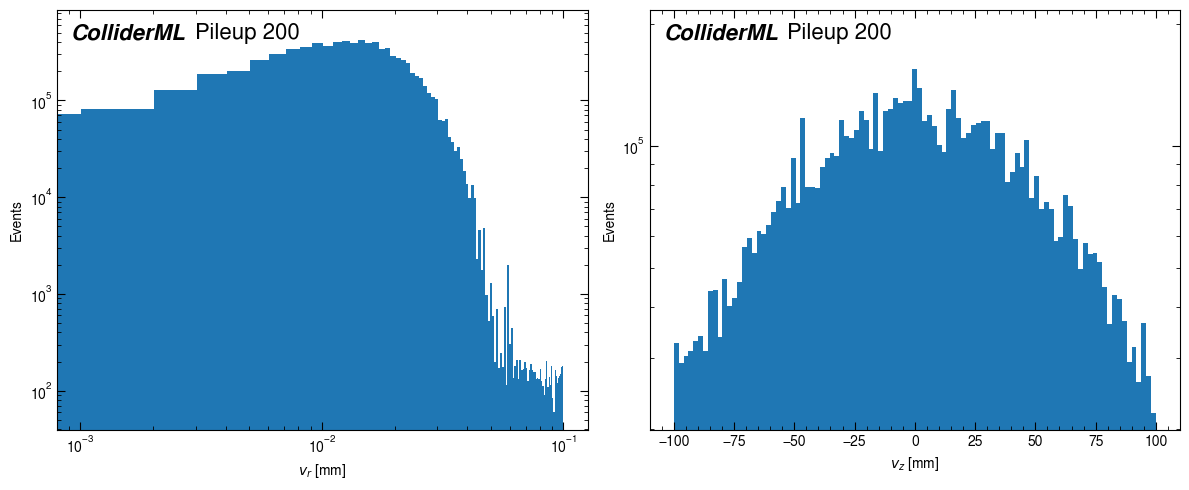

In [33]:
# Plot vr and vz distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate vr from vx and vy
vr = np.sqrt(generator_particles["vx"]**2 + generator_particles["vy"]**2)

# Plot vr
bins_r = np.linspace(0, 0.1, 100)
counts_r = np.histogram(vr, bins=bins_r)[0]
axes[0].bar(bins_r[:-1], counts_r, width=bins_r[1]-bins_r[0], align='edge')
axes[0].set_xlabel("$v_r$ [mm]")
axes[0].set_ylabel("Events")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
atl.atlasify("Pileup 200", axes=axes[0])

# Plot vz
bins_z = np.linspace(-100, 100, 100)
counts_z = np.histogram(generator_particles["vz"], bins=bins_z)[0]
axes[1].bar(bins_z[:-1], counts_z, width=bins_z[1]-bins_z[0], align='edge')
axes[1].set_xlabel("$v_z$ [mm]")
axes[1].set_ylabel("Events")
axes[1].set_yscale("log")
atl.atlasify("Pileup 200", axes=axes[1])

plt.tight_layout()
plt.show()


In [18]:
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root"
hard_scatter_batch = EDM4hepEventBatch(edm_input_file, events=(0, 100), full_load=False)

In [19]:
hard_scatter_particles = hard_scatter_batch.get_particles_df()

In [20]:
hard_scatter_generator_particles = hard_scatter_particles[hard_scatter_particles["created_in_simulation"] == False]
hard_scatter_generator_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,-4.928942,0.93827,-0.005129,-0.001055,-56.738349,...,6999.999937,0,0,0.005237,7000.000000,6999.061730,0,False,0,0
1,0,1,21,0,0.000000,-4.928942,0.00000,-0.005129,-0.001055,-56.738349,...,1210.616972,0,1,0.005237,1210.616972,1210.616972,1,False,0,0
2,0,2,2,0,0.666667,-4.928942,0.33000,-0.005129,-0.001055,-56.738349,...,3436.204368,1,2,0.005237,3436.204384,3435.874384,2,False,0,0
3,0,3,2103,0,0.333333,-4.928942,0.77133,-0.005129,-0.001055,-56.738349,...,2353.178474,2,3,0.005237,2353.178600,2352.407270,3,False,0,0
4,0,4,2212,0,1.000000,-4.928942,0.93827,-0.005129,-0.001055,-56.738349,...,-6999.999937,3,3,0.005237,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184584,31,854,310,0,0.000000,3.443748,0.49761,-0.677219,-0.386740,19.188252,...,1.175174,3366,3367,0.779868,2.273084,1.775474,854,False,0,0
184585,31,855,-321,16777216,-1.000000,3.449984,0.49368,-2.068458,-1.242569,20.081144,...,4.640575,3367,3368,2.412985,9.261730,8.768050,855,False,0,0
184586,31,856,111,0,0.000000,3.449984,0.13498,-2.068458,-1.242569,20.081144,...,1.633258,3368,3369,2.412985,4.383868,4.248888,856,False,0,0
184587,31,857,111,0,0.000000,4.168791,0.13498,-158.056769,-87.482889,131.563764,...,0.545709,3369,3370,180.652146,1.104403,0.969423,857,False,0,0


In [21]:
hard_scatter_generator_particles[hard_scatter_generator_particles.particle_id == 1]

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
1,0,1,21,0,0.000000,-4.928942,0.0,-0.005129,-0.001055,-56.738349,...,1210.616972,0,1,0.005237,1210.616972,1210.616972,1,False,0,0
2284,1,1,3,0,-0.333333,-9.055692,0.0,0.003952,0.004528,-92.366032,...,159.195211,0,1,0.006010,159.195211,159.195211,1,False,0,0
4969,2,1,21,0,0.000000,-2.737528,0.0,0.011662,0.016506,-79.517861,...,108.645622,0,1,0.020210,108.645622,108.645622,1,False,0,0
8179,3,1,21,0,0.000000,6.789205,0.0,0.007669,-0.006790,-31.421740,...,326.818203,0,1,0.010243,326.818203,326.818203,1,False,0,0
10339,4,1,21,0,0.000000,-2.097912,0.0,0.001736,-0.013043,-29.877186,...,1195.934331,0,1,0.013159,1195.934331,1195.934331,1,False,0,0
14562,5,1,21,0,0.000000,8.047857,0.0,-0.001989,-0.010170,-48.673026,...,2923.400733,0,1,0.010362,2923.400733,2923.400733,1,False,0,0
20318,6,1,21,0,0.000000,1.029776,0.0,-0.008056,-0.007944,71.344288,...,1041.534115,0,1,0.011314,1041.534115,1041.534115,1,False,0,0
27034,7,1,21,0,0.000000,-8.570405,0.0,0.024970,-0.000191,-84.045938,...,2862.915849,0,1,0.024971,2862.915849,2862.915849,1,False,0,0
33479,8,1,1,0,-0.333333,4.895465,0.0,0.025526,-0.001706,9.439543,...,664.009724,0,1,0.025583,664.009724,664.009724,1,False,0,0
42090,9,1,1,0,-0.333333,-3.677018,0.0,-0.002800,0.012396,60.780303,...,808.874476,0,1,0.012708,808.874476,808.874476,1,False,0,0


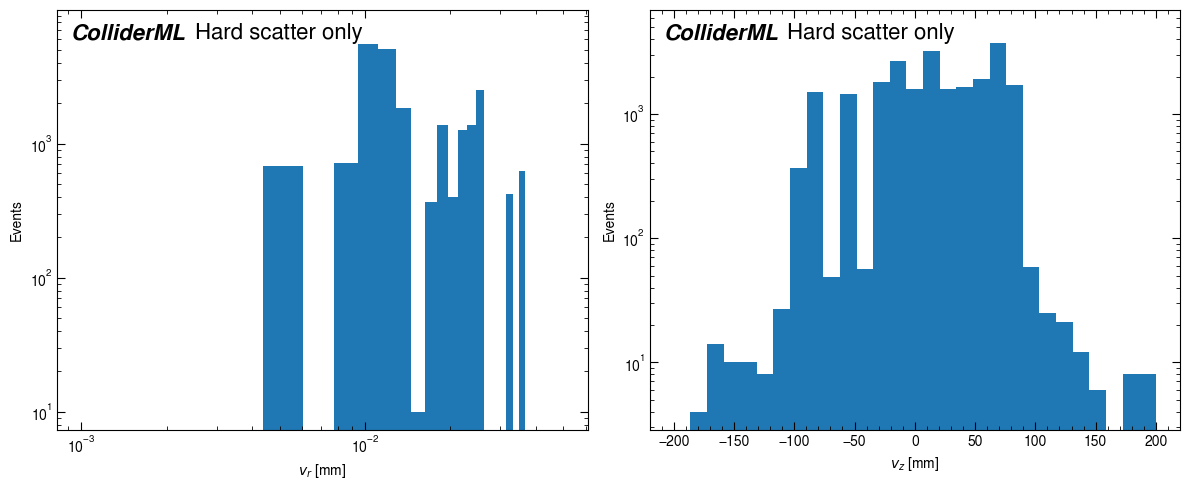

In [27]:
# Plot vr and vz distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Calculate vr from vx and vy
vr = np.sqrt(hard_scatter_generator_particles["vx"]**2 + hard_scatter_generator_particles["vy"]**2)

# Plot vr
bins_r = np.linspace(0.001, 0.05, 30)
counts_r = np.histogram(vr, bins=bins_r)[0]
axes[0].bar(bins_r[:-1], counts_r, width=bins_r[1]-bins_r[0], align='edge')
axes[0].set_xlabel("$v_r$ [mm]")
axes[0].set_ylabel("Events")
axes[0].set_yscale("log")
axes[0].set_xscale("log")
atl.atlasify("Hard scatter only", axes=axes[0])

# Plot vz
bins_z = np.linspace(-200, 200, 30)
counts_z = np.histogram(hard_scatter_generator_particles["vz"], bins=bins_z)[0]
axes[1].bar(bins_z[:-1], counts_z, width=bins_z[1]-bins_z[0], align='edge')
axes[1].set_xlabel("$v_z$ [mm]")
axes[1].set_ylabel("Events")
axes[1].set_yscale("log")
atl.atlasify("Hard scatter only", axes=axes[1])

plt.tight_layout()
plt.show()


## Pileup Stats

In [3]:
from parquet_loading_utils import *

In [17]:
global_event_id = None
chunk_size = 100

In [18]:
events_start = 0
events_end = events_start + chunk_size
events_range = f"events{events_start}-{events_end-1}"

In [21]:
# Update file paths to point to parquet files
particles_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/truth/particles/full_pileup.ttbar.v1.truth.particles.{event_range}.parquet"

In [20]:
# Test loading a single event from parquet with improved functions
parquet_particles_df = load_all_particles_parquet(particles_file, event_id=global_event_id)

print(f"Loaded event {global_event_id}:")
print(f"  Particles: {len(parquet_particles_df)} rows")

Loaded event None:
  Particles: 17770495 rows


In [22]:
n_vertices_total = []
for event_id in parquet_particles_df.event_id.unique():
    event_particles = parquet_particles_df[parquet_particles_df.event_id == event_id]
    n_vertices = len(event_particles.vertex_primary.unique())
    n_vertices_total.append(n_vertices)
    print(f"Event ID {event_id} has {n_vertices} primary vertices.")

Event ID 0 has 199 primary vertices.
Event ID 1 has 184 primary vertices.
Event ID 2 has 196 primary vertices.
Event ID 3 has 175 primary vertices.
Event ID 4 has 220 primary vertices.
Event ID 5 has 230 primary vertices.
Event ID 6 has 200 primary vertices.
Event ID 7 has 235 primary vertices.
Event ID 8 has 212 primary vertices.
Event ID 9 has 197 primary vertices.
Event ID 10 has 208 primary vertices.
Event ID 11 has 202 primary vertices.
Event ID 12 has 189 primary vertices.
Event ID 13 has 216 primary vertices.
Event ID 14 has 235 primary vertices.
Event ID 15 has 206 primary vertices.
Event ID 16 has 212 primary vertices.
Event ID 17 has 212 primary vertices.
Event ID 18 has 221 primary vertices.
Event ID 19 has 203 primary vertices.
Event ID 20 has 206 primary vertices.
Event ID 21 has 193 primary vertices.
Event ID 22 has 227 primary vertices.
Event ID 23 has 218 primary vertices.
Event ID 24 has 203 primary vertices.
Event ID 25 has 190 primary vertices.
Event ID 26 has 209 pr

In [27]:
# Iterate over 10 chunks to collect pileup multiplicities
import scipy.stats as st

chunk_size = 100
n_chunks = 20
mu = 200.0  # Expected pileup mean

all_n_vertices = []

for chunk_num in tqdm(range(n_chunks), desc="Loading chunks"):
    events_start = chunk_num * chunk_size
    events_end = events_start + chunk_size
    event_range = f"events{events_start}-{events_end-1}"
    
    particles_file = f"/global/cfs/cdirs/m4958/data/ColliderML/simulation/full_pileup/ttbar/v1/parquet/truth/particles/full_pileup.ttbar.v1.truth.particles.{event_range}.parquet"
    
    try:
        parquet_particles_df = load_all_particles_parquet(particles_file, event_id=None)
        
        for event_id in parquet_particles_df.event_id.unique():
            event_particles = parquet_particles_df[parquet_particles_df.event_id == event_id]
            n_vertices = len(event_particles.vertex_primary.unique())
            # Subtract 1 for hard scatter vertex to get pileup multiplicity
            all_n_vertices.append(n_vertices - 1)
    except Exception as e:
        print(f"Warning: Could not load chunk {chunk_num}: {e}")
        continue

k = np.array(all_n_vertices)
k = k[k >= 0]  # Filter out any negative values
print(f"Loaded {len(k)} events. k mean={k.mean():.2f}, std={k.std(ddof=1):.2f}")

Loading chunks: 100%|██████████| 20/20 [02:30<00:00,  7.54s/it]

Loaded 2000 events. k mean=200.22, std=14.30


Fitted Poisson μ = 200.22
Empirical mean = 200.22, var = 204.59
For Poisson: mean should equal variance. Ratio var/mean = 1.022 (should be ~1)


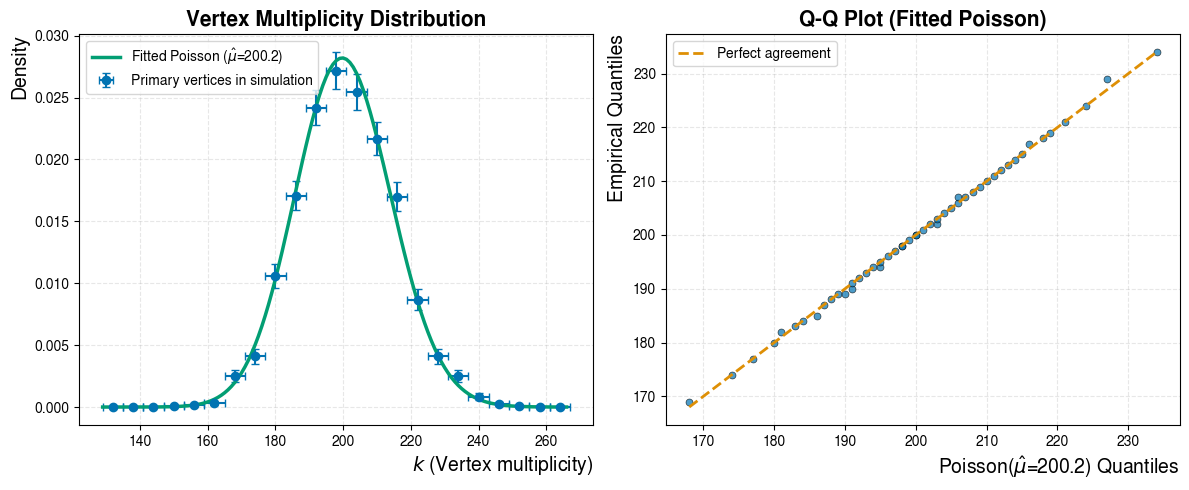

In [36]:
# Plot histogram and compare to Poisson fit
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

if len(k):
    # Fit Poisson to data: MLE estimate for Poisson is simply the sample mean
    fitted_mu = np.mean(k)
    
    bin_width = 6
    bins = np.arange(max(1, int(mu - 5*np.sqrt(mu))), int(mu + 5*np.sqrt(mu)) + 2, bin_width)
    counts, bin_edges = np.histogram(k, bins=bins, density=True)
    raw_counts, _ = np.histogram(k, bins=bins, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges) / 2
    
    # Calculate uncertainty on density using Poisson statistics
    total_events = len(k)
    counts_err = np.sqrt(raw_counts) / (total_events * bin_width)
    
    ax[0].errorbar(bin_centers, counts, xerr=bin_widths, yerr=counts_err, fmt='o', 
                   color='#0173B2', label="Primary vertices in simulation", 
                   markersize=6, capsize=3, linewidth=1.5)
    
    x = np.arange(bins[0], bins[-1])
    
    # Plot fitted Poisson
    ax[0].plot(x, st.poisson(fitted_mu).pmf(x), color='#029E73', 
               linewidth=2.5, label=f"Fitted Poisson ($\\hat{{\\mu}}$={fitted_mu:.1f})")
    
    ax[0].legend(frameon=True, loc='best')
    ax[0].set_ylabel("Density", fontsize=14)

ax[0].set_xlabel("$k$ (Vertex multiplicity)", fontsize=14)
ax[0].set_title("Vertex Multiplicity Distribution", fontsize=15, fontweight='bold')
ax[0].grid(True, alpha=0.3, linestyle='--')
atl.set_xlabel(ax[0], "$k$ (Vertex multiplicity)")
atl.set_ylabel(ax[0], "Density")

# Print statistics
emp_mean = float(np.mean(k)) if len(k) else float('nan')
emp_var = float(np.var(k, ddof=1)) if len(k) > 1 else float('nan')
print(f"Fitted Poisson μ = {fitted_mu:.2f}")
print(f"Empirical mean = {emp_mean:.2f}, var = {emp_var:.2f}")
print(f"For Poisson: mean should equal variance. Ratio var/mean = {emp_var/emp_mean:.3f} (should be ~1)")

if len(k) >= 10:
    empirical = np.sort(k)
    quantiles = np.linspace(0.01, 0.99, 50)
    q_emp = np.quantile(empirical, quantiles)
    # Use fitted mu for Q-Q plot
    q_pois = st.poisson(fitted_mu).ppf(quantiles)
    ax[1].plot(q_pois, q_emp, 'o', ms=5, color='#0173B2', 
               alpha=0.7, markeredgecolor='black', markeredgewidth=0.5)
    ax[1].plot([q_pois.min(), q_pois.max()], [q_pois.min(), q_pois.max()], 
               color='#DE8F05', linestyle='--', linewidth=2, 
               label='Perfect agreement')
    ax[1].set_title("Q-Q Plot (Fitted Poisson)", fontsize=15, fontweight='bold')
    ax[1].legend(frameon=True, loc='best')
    ax[1].grid(True, alpha=0.3, linestyle='--')

ax[1].set_xlabel(f"Poisson($\\hat{{\\mu}}$={fitted_mu:.1f}) Quantiles", fontsize=14)
ax[1].set_ylabel("Empirical Quantiles", fontsize=14)
atl.set_xlabel(ax[1], f"Poisson($\\hat{{\\mu}}$={fitted_mu:.1f}) Quantiles")
atl.set_ylabel(ax[1], "Empirical Quantiles")

plt.tight_layout()
plt.show()

In [37]:
# Save each subplot as separate PDF
fig_left, ax_left = plt.subplots(1, 1, figsize=(6, 5))
if len(k):
    ax_left.errorbar(bin_centers, counts, xerr=bin_widths, yerr=counts_err, fmt='o', 
                     color='#0173B2', label="Primary vertices in simulation", 
                     markersize=6, capsize=3, linewidth=1.5)
    ax_left.plot(x, st.poisson(fitted_mu).pmf(x), color='#029E73', 
                 linewidth=2.5, label=f"Fitted Poisson ($\\hat{{\\mu}}$={fitted_mu:.1f})")
    ax_left.legend(frameon=True, loc='best')
ax_left.set_xlabel("$k$ (Vertex multiplicity)", fontsize=14)
ax_left.set_ylabel("Density", fontsize=14)
ax_left.set_title("Vertex Multiplicity Distribution", fontsize=15, fontweight='bold')
ax_left.grid(True, alpha=0.3, linestyle='--')
atl.set_xlabel(ax_left, "$k$ (Vertex multiplicity)")
atl.set_ylabel(ax_left, "Density")
plt.tight_layout()
fig_left.savefig("plots/pileup_distribution2.pdf", dpi=300, format='pdf')
plt.close(fig_left)

if len(k) >= 10:
    fig_right, ax_right = plt.subplots(1, 1, figsize=(6, 5))
    ax_right.plot(q_pois, q_emp, 'o', ms=5, color='#0173B2', 
                  alpha=0.7, markeredgecolor='black', markeredgewidth=0.5)
    ax_right.plot([q_pois.min(), q_pois.max()], [q_pois.min(), q_pois.max()], 
                  color='#DE8F05', linestyle='--', linewidth=2, 
                  label='Perfect agreement')
    ax_right.set_xlabel(f"Poisson($\\hat{{\\mu}}$={fitted_mu:.1f}) Quantiles", fontsize=14)
    ax_right.set_ylabel("Empirical Quantiles", fontsize=14)
    ax_right.set_title("Q-Q Plot (Fitted Poisson)", fontsize=15, fontweight='bold')
    ax_right.legend(frameon=True, loc='best')
    ax_right.grid(True, alpha=0.3, linestyle='--')
    atl.set_xlabel(ax_right, f"Poisson($\\hat{{\\mu}}$={fitted_mu:.1f}) Quantiles")
    atl.set_ylabel(ax_right, "Empirical Quantiles")
    plt.tight_layout()
    fig_right.savefig("plots/pileup_qq_plot2.pdf", dpi=300, format='pdf')
    plt.close(fig_right)

print("Saved pileup_distribution2.pdf and pileup_qq_plot2.pdf")

Saved pileup_distribution2.pdf and pileup_qq_plot2.pdf
